# Análisis Exploratorio de Fraude en Transacciones con Tarjetas de Crédito
## Grupo 8 - Alabarca Yarlenis, Villarreal Antoine, Otero Felix, Jean

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("credit_card_fraud_10k.csv")

| Feature Name | Descripción |
|---|---|
| `transaction_id` | Identificador único para cada transacción |
| `amount` | Monto de la transacción |
| `transaction_hour` | Hora de la transacción (0–23) |
| `merchant_category` | Tipo de comercio |
| `foreign_transaction` | Indica si la transacción es internacional (0/1) |
| `location_mismatch` | Diferencia entre la ubicación de facturación y la ubicación de la transacción (0/1) |
| `device_trust_score` | Puntaje de confianza del dispositivo (0–100) |
| `velocity_last_24h` | Número de transacciones realizadas en las últimas 24 horas |
| `cardholder_age` | Edad del titular de la tarjeta |

In [7]:
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [8]:
df.columns

Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='str')

In [9]:
df.shape

(10000, 10)

### Estructura de Datos

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  str    
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), str(1)
memory usage: 781.4 KB


In [11]:
df.dtypes

transaction_id           int64
amount                 float64
transaction_hour         int64
merchant_category          str
foreign_transaction      int64
location_mismatch        int64
device_trust_score       int64
velocity_last_24h        int64
cardholder_age           int64
is_fraud                 int64
dtype: object

In [12]:
df.nunique()

transaction_id         10000
amount                  8788
transaction_hour          24
merchant_category          5
foreign_transaction        2
location_mismatch          2
device_trust_score        75
velocity_last_24h         10
cardholder_age            52
is_fraud                   2
dtype: int64

### buscar duplicados

In [15]:
# buscar duplicados
df.duplicated().sum()

np.int64(0)

In [16]:
# verificar si el identificador de transaccion se duplica
df["transaction_id"].duplicated().sum()

np.int64(0)

### Datos Faltantes

In [18]:
# Datos faltantes
df.isnull().sum()

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

## Variable Objetivo

In [19]:
df["is_fraud"].value_counts()

is_fraud
0    9849
1     151
Name: count, dtype: int64

In [20]:
df["is_fraud"].value_counts(normalize=True) * 100

is_fraud
0    98.49
1     1.51
Name: proportion, dtype: float64

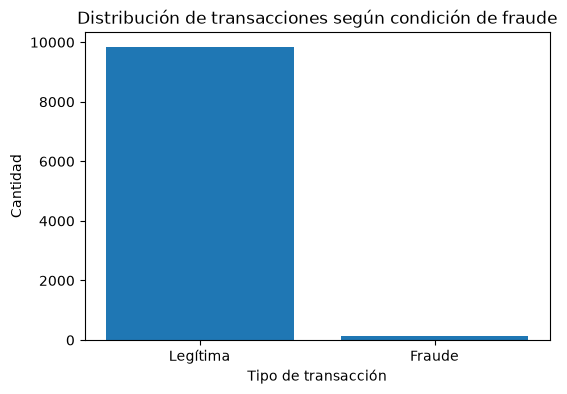

In [22]:

conteos = df["is_fraud"].value_counts().sort_index()

plt.figure(figsize=(6, 4))

plt.bar(
    ["Legítima", "Fraude"],
    conteos.values
)

plt.title("Distribución de transacciones según condición de fraude")
plt.xlabel("Tipo de transacción")
plt.ylabel("Cantidad")

plt.show()

In [23]:
df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [24]:
variables_resumen = [
    "is_fraud",
    "device_trust_score",
    "velocity_last_24h",
    "amount"
]

tabla_descriptiva = df[variables_resumen].agg([
    "mean",
    "median",
    "min",
    "max"
]).T

tabla_descriptiva

,mean,median,min,max
is_fraud,0.015100,0.000,0.0,1.00
device_trust_score,61.798900,62.000,25.0,99.00
velocity_last_24h,2.008900,2.000,0.0,9.00
amount,175.949849,122.095,0.0,1471.04


In [25]:
df.groupby("is_fraud")["device_trust_score"].agg([
    "count",
    "mean",
    "median",
    "min",
    "max"
])

,count,mean,median,min,max
is_fraud,,,,,
0,9849,62.165804,62.0,25,99
1,151,37.867550,32.0,25,99


In [26]:
df.groupby("is_fraud")["velocity_last_24h"].agg([
    "count",
    "mean",
    "median",
    "min",
    "max"
])

,count,mean,median,min,max
is_fraud,,,,,
0,9849,1.990557,2.0,0,9
1,151,3.205298,3.0,0,7


In [27]:
df.groupby("is_fraud")["amount"].agg([
    "count",
    "mean",
    "median",
    "min",
    "max"
])

,count,mean,median,min,max
is_fraud,,,,,
0,9849,175.333015,122.11,0.00,1471.04
1,151,216.182980,118.94,0.11,1185.07


### posible hipotesis
### Las transacciones fraudulentas presentan un menor device_trust_score y una mayor velocity_last_24h que las transacciones legítima